# Training Dynamics: Gradient Descent Optimizers

**Learning Objectives:**
- Understand how Batch Gradient Descent works and its limitations
- Learn why sharp minima lead to overfitting
- Discover how Stochastic Gradient Descent (SGD) prevents overfitting through noise
- Master Adam optimizer and when to use each approach

**Estimated Time:** 40-50 minutes

## Setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

## 1. The Optimization Challenge

Training a neural network means finding parameters that minimize the loss function. But **how** we compute and apply gradients dramatically affects:
- Training speed
- Final model quality
- Generalization to new data

We'll explore three fundamental approaches:
1. **Batch Gradient Descent (GD)**: Use entire dataset per update
2. **Stochastic Gradient Descent (SGD)**: Use small mini-batches
3. **Adam**: Adaptive learning with momentum

Let's start with the most basic approach.

Here is the updated explanation. I’ve refined the characteristics to highlight the "landscape" behavior we discussed—specifically how the exact nature of Batch GD can actually be a disadvantage when it comes to the quality of the minima it finds.

---

## 2. Batch Gradient Descent (GD)

### How It Works

Batch GD computes the gradient using **all training samples** before making a single update:

Where:

*  = total number of training samples
*  = learning rate
* The gradient is computed over the **entire dataset**

### Characteristics

✅ **Exact gradient**: Provides a perfect, non-noisy estimate of the true loss landscape.

✅ **Smooth convergence**: Follows a deterministic, "straight-line" path toward the nearest minimum.

✅ **Stable trajectory**: Guaranteed to reduce loss at every step (given a sufficiently small learning rate).

❌ **Prone to "Sharp" Minima**: Because there is no noise to "kick" the optimizer out of narrow pits, it often gets stuck in sharp, steep minima that generalize poorly to new data.

❌ **Lack of Exploration**: Unlike SGD, it cannot "jump" over small ridges or escape local traps through stochastic variance.

❌ **Computationally expensive**: Must process every single data point before moving the parameters once.

❌ **Memory intensive**: Often impossible to use with modern deep learning because the entire dataset cannot fit into GPU memory.

---

### What's Next?

Since we've looked at how Batch GD gets stuck, would you like me to rewrite the **Stochastic Gradient Descent (SGD)** section next to show how its "noisy" updates specifically solve these generalization and memory problems?

## 3. The Problem: Sharp Minima and Overfitting

### Understanding Sharp vs Flat Minima

Not all minima are equal! The loss landscape can have:

#### 🔴 Sharp Minima (Bad - Overfitting)
- **Steep walls**: Small parameter changes → Large loss changes
- **Memorization**: Model fits training data too precisely
- **Poor generalization**: Doesn't work well on new data
- **Fragile**: Sensitive to perturbations

#### 🟢 Flat Minima (Good - Generalization)
- **Wide valleys**: Parameters can vary without hurting loss
- **Robust patterns**: Model learned general features
- **Good generalization**: Works well on new data
- **Stable**: Insensitive to small changes

### Why Batch GD Falls Into Sharp Minima

Batch GD follows the exact gradient, which means it:
1. Takes the **most direct path** to the nearest minimum
2. Has **no exploration** - deterministic trajectory
3. **Cannot escape** once it reaches a minimum (gradient = 0)
4. Often finds sharp minima because they're **easier to fall into** (steep slopes guide gradient)

**Result**: The model overfits to the training data!

### Additional Problem: Saddle Points

In high-dimensional spaces (neural networks have millions of parameters!), **saddle points** are common:
- Gradient ≈ 0, but it's not a minimum
- Batch GD slows down dramatically
- Can stall optimization for many iterations

**Solution?** Add noise to escape sharp minima and saddle points!

![](https://miro.medium.com/v2/resize:fit:1400/1*HImasjOG6dh7EOshu-EYAw.png)

## 4. Stochastic Gradient Descent (SGD): The Power of Noise

### How It Works

Instead of using all data, SGD uses **small random mini-batches**:

$$\theta_{t+1} = \theta_t - \eta \cdot \nabla_{\theta} \frac{1}{B} \sum_{i \in \mathcal{B}_t} L(x_i, y_i; \theta)$$

Where:
- $\mathcal{B}_t$ = random mini-batch at step $t$ (typically 32-256 samples)
- $B$ = batch size (much smaller than $N$)

### Key Difference: Noisy Gradients

Each mini-batch gives a **different gradient estimate** → introduces **beneficial noise**

### Why Noise Helps

1. **Escapes Sharp Minima**
   - Noise "kicks" optimizer out of steep valleys
   - Prevents overfitting by not settling into overfit solutions
   - Explores the loss landscape

2. **Navigates Saddle Points**
   - Random perturbations break symmetry
   - Helps escape plateaus faster

3. **Finds Flat Minima**
   - Tends to settle in wide valleys
   - These represent better generalization

4. **Implicit Regularization**
   - Noise acts like regularization
   - Prevents model from fitting training data too precisely

5. **Computational Efficiency**
   - 100x smaller batches → 100x more updates per epoch
   - Faster convergence in practice

### 🔧 Mini-Exercise: Batch Size Impact

**TODO**: Experiment with different batch sizes:

1. Try `batch_size=1` (extreme stochasticity)
2. Try `batch_size=128` (moderate)
3. Try `batch_size=512` (large, closer to Batch GD)

**Observe**:
- How does noise level change?
- Which converges fastest?
- What's the trade-off?


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

batch_size = 1  # 👈 CHANGE THIS VALUE TO EXPERIMENT!

# ============================================================================


# Load and prepare Wine dataset (more challenging than Iris)
# Wine dataset: 178 samples, 13 features, 3 classes
print("Loading Wine dataset...")
wine = load_wine()
X, y = wine.data, wine.target
print(f"Dataset: {len(X)} samples, {X.shape[1]} features, {len(np.unique(y))} classes")

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=len(X_test), shuffle=False)


# Define a simple 3-layer MLP
class SimpleMLP(nn.Module):
    def __init__(self, input_size=13, hidden1=4, num_classes=3):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden1, num_classes)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        return x


# Initialize model, loss, and optimizer
model = SimpleMLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(f"\n{'='*60}")
print(f"Training with BATCH_SIZE = {batch_size}")
print(f"{'='*60}")
print(f"Dataset size: {len(X_train)} training samples")
print(f"Batches per epoch: {len(train_loader)}")
print(f"{'='*60}\n")

# Training loop with batch-level loss tracking
num_epochs =10
batch_losses = []  # Store loss for every batch
epoch_losses = []  # Store average loss per epoch
batch_indices = []  # Track batch number globally
batch_counter = 0

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Record batch loss
        batch_losses.append(loss.item())
        batch_indices.append(batch_counter)
        batch_counter += 1
        epoch_loss += loss.item()
    
    # Calculate average epoch loss
    avg_epoch_loss = epoch_loss / len(train_loader)
    epoch_losses.append(avg_epoch_loss)
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Avg Loss: {avg_epoch_loss:.4f}")

# Evaluate on test set
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    _, predicted = torch.max(test_outputs, 1)
    accuracy = (predicted == y_test_tensor).sum().item() / len(y_test_tensor)
    print(f"\n{'='*60}")
    print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"{'='*60}\n")


# ============================================================================
# Visualization: Loss Throughout Training
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Batch-level loss (shows noise/variance)
axes[0].plot(batch_indices, batch_losses, alpha=0.6, linewidth=0.8)
axes[0].set_xlabel('Batch Number', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title(f'Loss per Batch (Batch Size = {batch_size})', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(bottom=0)

# Plot 2: Epoch-level average loss (smoother trend)
axes[1].plot(range(1, num_epochs + 1), epoch_losses, marker='o', linewidth=2, markersize=4)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Average Loss', fontsize=12)
axes[1].set_title(f'Average Loss per Epoch (Batch Size = {batch_size})', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(bottom=0)

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/batch_size_loss_curves.png', dpi=150, bbox_inches='tight')
print("✅ Loss visualization saved!")
plt.show()


# ============================================================================
# Summary Statistics
# ============================================================================

print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"Batch Size:                {batch_size}")
print(f"Total Batches:             {batch_counter}")
print(f"Batches per Epoch:         {len(train_loader)}")
print(f"Final Epoch Loss:          {epoch_losses[-1]:.4f}")
print(f"Loss Std Dev (last epoch): {np.std(batch_losses[-len(train_loader):]):.4f}")
print(f"Test Accuracy:             {accuracy:.4f}")
print("="*60)
print("\n💡 TIP: Try different batch sizes and compare:")
print("   - Small batches (1-32): Noisier but can escape local minima")
print("   - Large batches (128+): Smoother but may converge to worse solutions")
print("="*60)

## 5. Adam: Adaptive Learning with Momentum

### The Motivation

SGD improved on Batch GD, but still has limitations:
- Single learning rate for all parameters
- Sensitive to learning rate choice
- Can oscillate in narrow valleys

**Adam** (Adaptive Moment Estimation) solves these issues.

### How Adam Works

Adam maintains two moving averages:

**1. First Moment (Momentum)**
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$

- Accumulates past gradients
- Smooths out noisy gradients
- Accelerates in consistent directions

**2. Second Moment (Adaptive Learning Rate)**
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$

- Tracks gradient variance
- Adapts learning rate per parameter
- Large gradients → smaller steps
- Small gradients → larger steps

**3. Parameter Update**
$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

Where $\hat{m}_t$ and $\hat{v}_t$ are bias-corrected estimates.

### Key Advantages

✅ **Adaptive learning rates**: Each parameter gets its own step size  
✅ **Momentum**: Smooths out SGD's noise while keeping benefits  
✅ **Robust defaults**: Works well with standard settings (lr=0.001, β₁=0.9, β₂=0.999)  
✅ **Fast convergence**: Often faster than SGD  
✅ **Less hyperparameter tuning**: More forgiving than SGD

### 🔧 Mini-Exercise: Adam Hyperparameters

**TODO**: Experiment with Adam's `betas` parameter:

1. Try `betas=(0.5, 0.999)` (less momentum)
2. Try `betas=(0.99, 0.999)` (more momentum)
3. Try `betas=(0.9, 0.99)` (faster adaptation)

**Observe**: How do these affect convergence speed and stability?

⏱️ ~5 minutes


LEARNING RATE SCHEDULER EXPERIMENT
Scheduler Type: StepLR
Initial Learning Rate: 0.01
  - Step Size: 10 epochs
  - Gamma: 0.5 (multiply LR by this factor)

Loading Wine dataset...
Dataset: 178 samples, 13 features, 3 classes

Training with Adam Optimizer + StepLR Scheduler
Batch Size:  8 (FIXED)
Beta1 (β₁):  0.9 - momentum for gradient mean
Beta2 (β₂):  0.999 - momentum for gradient variance
Initial LR:  0.01
Dataset size: 142 training samples
Batches per epoch: 18

Epoch [10/50], LR: 0.010000, Avg Loss: 0.0212
Epoch [20/50], LR: 0.005000, Avg Loss: 0.0098
Epoch [30/50], LR: 0.002500, Avg Loss: 0.0069
Epoch [40/50], LR: 0.001250, Avg Loss: 0.0058
Epoch [50/50], LR: 0.000625, Avg Loss: 0.0053

Test Accuracy: 0.9722 (97.22%)

✅ Visualization saved to outputs!


/var/folders/bp/hxsq_5h96wv5hnzrf6mldthm0000gp/T/ipykernel_77938/1827221707.py:300: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


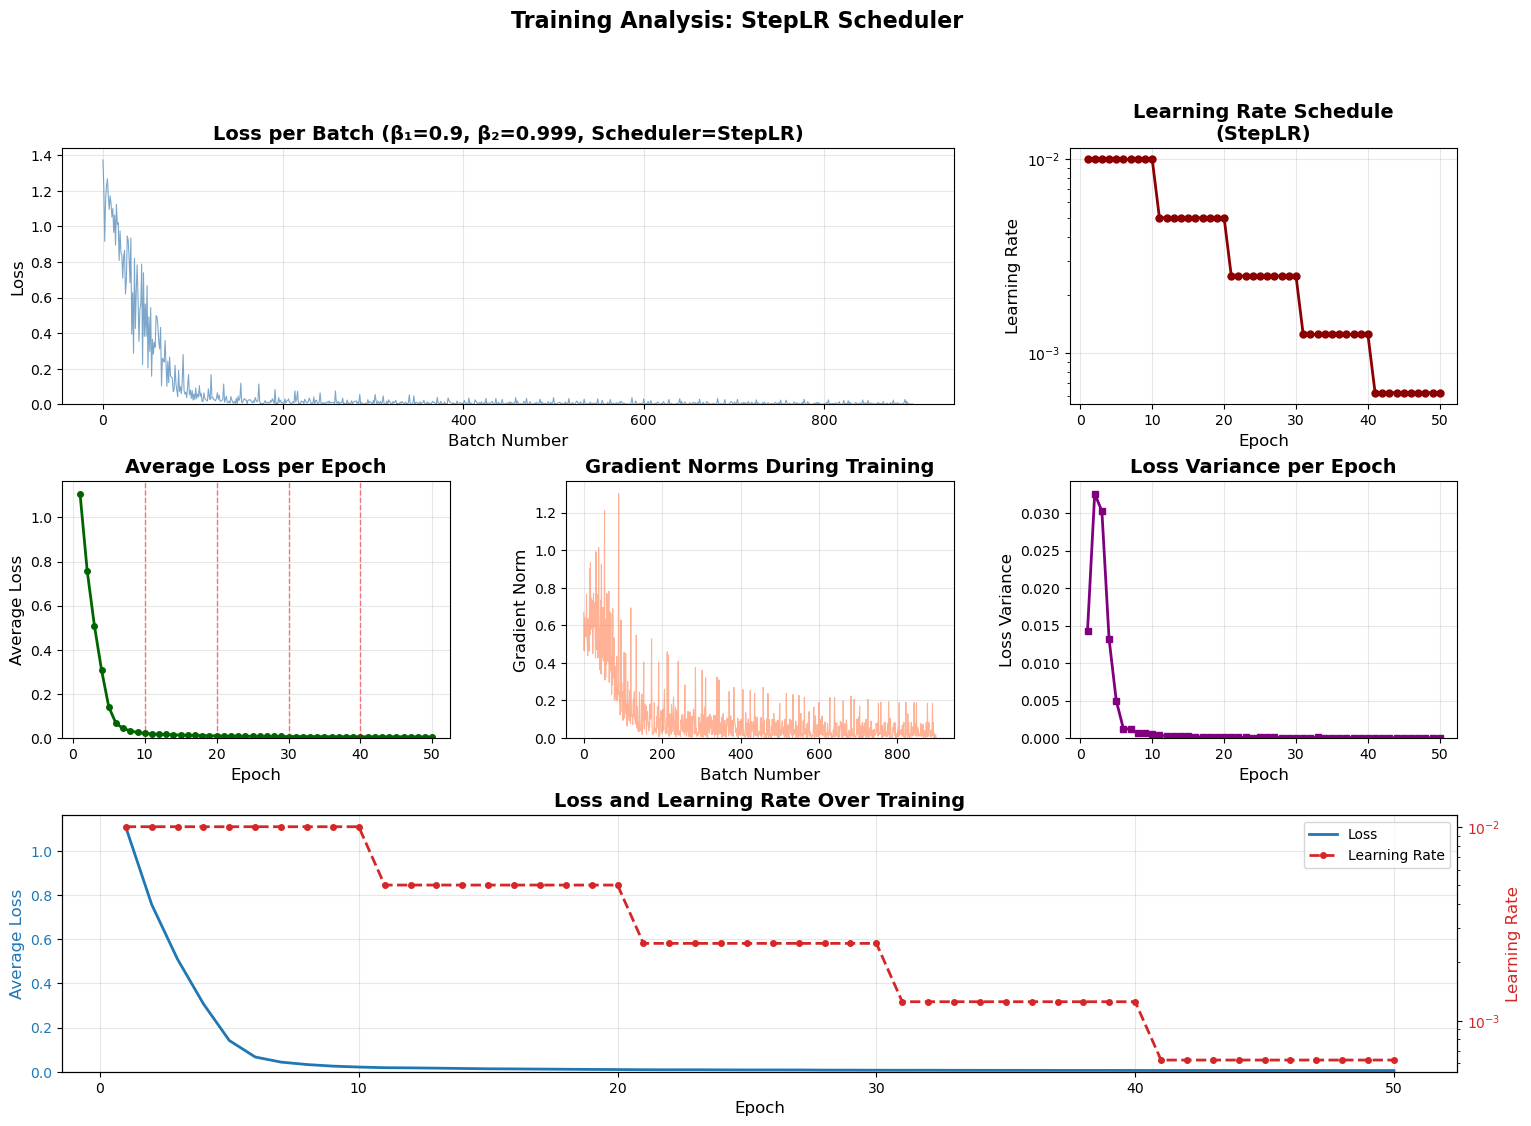


TRAINING SUMMARY
Optimizer:                 Adam (β₁=0.9, β₂=0.999)
Scheduler:                 StepLR
Initial Learning Rate:     0.01
Final Learning Rate:       0.00062500
LR Reduction Factor:       16.00x
Batch Size:                8 (fixed)
Total Batches:             900
Batches per Epoch:         18
Final Epoch Loss:          0.0053
Best Epoch Loss:           0.0053 (Epoch 50)
Loss Improvement:          1.1033
Loss Std Dev (last epoch): 0.0068
Avg Gradient Norm:         0.1142
Test Accuracy:             0.9722 (97.22%)

LEARNING RATE SCHEDULE ANALYSIS
Step Decay Schedule:
  • Reduces LR by 0.5x every 10 epochs
  • Total reductions: 5
  • LR values: 0.010000 → 0.005000 → 0.002500 → 0.001250 → 0.000625 → 0.000313

💡 EXPERIMENT WITH DIFFERENT SCHEDULERS:

1. StepLR - Good for stable, predictable decay
   • step_size=10, gamma=0.5: Halve LR every 10 epochs
   • step_size=5, gamma=0.7: More frequent, gentler decay
   • Best for: When you know roughly when to reduce LR

2. ExponentialLR 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import StepLR, ExponentialLR, CosineAnnealingLR, ReduceLROnPlateau
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Fixed batch size
batch_size = 8

# Adam optimizer beta parameters
# 👇 CHANGE THESE VALUES TO EXPERIMENT! 👇
beta1 = 0.9   # Controls exponential decay for first moment (mean of gradients)
beta2 = 0.999 # Controls exponential decay for second moment (variance of gradients)
# 👆 TRY VALUES LIKE: (0.9, 0.999), (0.5, 0.999), (0.9, 0.9), (0.99, 0.999) 👆

# Learning Rate Scheduler Configuration
# 👇 CHOOSE YOUR SCHEDULER TYPE AND PARAMETERS! 👇
scheduler_type = 'StepLR'  # Options: 'StepLR', 'ExponentialLR', 'CosineAnnealingLR', 'ReduceLROnPlateau', 'None'
initial_lr = 0.01

# Scheduler-specific parameters
step_size = 10        # For StepLR: decay LR every N epochs
gamma = 0.5           # For StepLR/ExponentialLR: multiply LR by this factor
T_max = 50            # For CosineAnnealingLR: number of epochs for one cosine cycle
patience = 5          # For ReduceLROnPlateau: wait N epochs before reducing
threshold = 0.01      # For ReduceLROnPlateau: minimum change to count as improvement
# 👆 EXPERIMENT WITH DIFFERENT SCHEDULERS AND PARAMETERS! 👆

# ============================================================================

print(f"\n{'='*70}")
print(f"LEARNING RATE SCHEDULER EXPERIMENT")
print(f"{'='*70}")
print(f"Scheduler Type: {scheduler_type}")
print(f"Initial Learning Rate: {initial_lr}")
if scheduler_type == 'StepLR':
    print(f"  - Step Size: {step_size} epochs")
    print(f"  - Gamma: {gamma} (multiply LR by this factor)")
elif scheduler_type == 'ExponentialLR':
    print(f"  - Gamma: {gamma} (LR decay factor per epoch)")
elif scheduler_type == 'CosineAnnealingLR':
    print(f"  - T_max: {T_max} epochs (cosine cycle length)")
elif scheduler_type == 'ReduceLROnPlateau':
    print(f"  - Patience: {patience} epochs")
    print(f"  - Threshold: {threshold}")
    print(f"  - Factor: {gamma}")
print(f"{'='*70}\n")

# Load and prepare Wine dataset
print("Loading Wine dataset...")
wine = load_wine()
X, y = wine.data, wine.target
print(f"Dataset: {len(X)} samples, {X.shape[1]} features, {len(np.unique(y))} classes")

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=len(X_test), shuffle=False)


# Define a simple 3-layer MLP
class SimpleMLP(nn.Module):
    def __init__(self, input_size=13, hidden1=4, num_classes=3):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden1, num_classes)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        return x


# Initialize model, loss, and optimizer
model = SimpleMLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=initial_lr, betas=(beta1, beta2))

# Initialize learning rate scheduler
if scheduler_type == 'StepLR':
    scheduler = StepLR(optimizer, step_size=step_size, gamma=gamma)
elif scheduler_type == 'ExponentialLR':
    scheduler = ExponentialLR(optimizer, gamma=gamma)
elif scheduler_type == 'CosineAnnealingLR':
    scheduler = CosineAnnealingLR(optimizer, T_max=T_max)
elif scheduler_type == 'ReduceLROnPlateau':
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=gamma, 
                                  patience=patience, threshold=threshold, verbose=True)
else:
    scheduler = None

print(f"\n{'='*70}")
print(f"Training with Adam Optimizer + {scheduler_type if scheduler_type != 'None' else 'No'} Scheduler")
print(f"{'='*70}")
print(f"Batch Size:  {batch_size} (FIXED)")
print(f"Beta1 (β₁):  {beta1} - momentum for gradient mean")
print(f"Beta2 (β₂):  {beta2} - momentum for gradient variance")
print(f"Initial LR:  {initial_lr}")
print(f"{'='*70}")
print(f"Dataset size: {len(X_train)} training samples")
print(f"Batches per epoch: {len(train_loader)}")
print(f"{'='*70}\n")

# Training loop with comprehensive tracking
num_epochs = 50
batch_losses = []      # Store loss for every batch
epoch_losses = []      # Store average loss per epoch
batch_indices = []     # Track batch number globally
batch_counter = 0
learning_rates = []    # Track learning rate at each epoch
gradient_norms = []    # Track gradient statistics
gradient_indices = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)
    
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        
        # Calculate gradient norm before optimizer step (for analysis)
        total_norm = 0.0
        for p in model.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2)
                total_norm += param_norm.item() ** 2
        total_norm = total_norm ** 0.5
        gradient_norms.append(total_norm)
        gradient_indices.append(batch_counter)
        
        optimizer.step()
        
        # Record batch loss
        batch_losses.append(loss.item())
        batch_indices.append(batch_counter)
        batch_counter += 1
        epoch_loss += loss.item()
    
    # Calculate average epoch loss
    avg_epoch_loss = epoch_loss / len(train_loader)
    epoch_losses.append(avg_epoch_loss)
    
    # Step the scheduler
    if scheduler is not None:
        if isinstance(scheduler, ReduceLROnPlateau):
            # ReduceLROnPlateau needs the validation loss
            scheduler.step(avg_epoch_loss)
        else:
            scheduler.step()
    
    # Print progress every 10 epochs with learning rate info
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], LR: {current_lr:.6f}, Avg Loss: {avg_epoch_loss:.4f}")

# Evaluate on test set
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    _, predicted = torch.max(test_outputs, 1)
    accuracy = (predicted == y_test_tensor).sum().item() / len(y_test_tensor)
    print(f"\n{'='*70}")
    print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"{'='*70}\n")


# ============================================================================
# Visualization: Loss, Gradient Behavior, and Learning Rate Schedule
# ============================================================================

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Plot 1: Batch-level loss (shows optimization dynamics)
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(batch_indices, batch_losses, alpha=0.7, linewidth=0.8, color='steelblue')
ax1.set_xlabel('Batch Number', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title(f'Loss per Batch (β₁={beta1}, β₂={beta2}, Scheduler={scheduler_type})', 
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# Plot 2: Learning Rate Schedule Over Time
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(range(1, num_epochs + 1), learning_rates, marker='o', linewidth=2, 
         markersize=5, color='darkred')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Learning Rate', fontsize=12)
ax2.set_title(f'Learning Rate Schedule\n({scheduler_type})', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')  # Log scale to better visualize exponential decay

# Plot 3: Epoch-level average loss with LR annotations
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(range(1, num_epochs + 1), epoch_losses, marker='o', linewidth=2, 
         markersize=4, color='darkgreen')
# Mark epochs where learning rate changed significantly
if scheduler_type == 'StepLR':
    for i in range(step_size, num_epochs, step_size):
        ax3.axvline(x=i, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('Average Loss', fontsize=12)
ax3.set_title(f'Average Loss per Epoch', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_ylim(bottom=0)

# Plot 4: Gradient norms over time
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(gradient_indices, gradient_norms, alpha=0.6, linewidth=0.8, color='coral')
ax4.set_xlabel('Batch Number', fontsize=12)
ax4.set_ylabel('Gradient Norm', fontsize=12)
ax4.set_title(f'Gradient Norms During Training', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.set_ylim(bottom=0)

# Plot 5: Loss variance per epoch (shows stability)
ax5 = fig.add_subplot(gs[1, 2])
loss_variances = []
for epoch in range(num_epochs):
    start_idx = epoch * len(train_loader)
    end_idx = (epoch + 1) * len(train_loader)
    epoch_batch_losses = batch_losses[start_idx:end_idx]
    loss_variances.append(np.var(epoch_batch_losses))
ax5.plot(range(1, num_epochs + 1), loss_variances, marker='s', linewidth=2, 
         markersize=4, color='purple')
ax5.set_xlabel('Epoch', fontsize=12)
ax5.set_ylabel('Loss Variance', fontsize=12)
ax5.set_title(f'Loss Variance per Epoch', fontsize=14, fontweight='bold')
ax5.grid(True, alpha=0.3)
ax5.set_ylim(bottom=0)

# Plot 6: Loss vs Learning Rate (combined view)
ax6 = fig.add_subplot(gs[2, :])
color = 'tab:blue'
ax6.set_xlabel('Epoch', fontsize=12)
ax6.set_ylabel('Average Loss', color=color, fontsize=12)
ax6.plot(range(1, num_epochs + 1), epoch_losses, color=color, linewidth=2, label='Loss')
ax6.tick_params(axis='y', labelcolor=color)
ax6.set_ylim(bottom=0)
ax6.grid(True, alpha=0.3)

# Create second y-axis for learning rate
ax6b = ax6.twinx()
color = 'tab:red'
ax6b.set_ylabel('Learning Rate', color=color, fontsize=12)
ax6b.plot(range(1, num_epochs + 1), learning_rates, color=color, linewidth=2, 
          linestyle='--', marker='o', markersize=4, label='Learning Rate')
ax6b.tick_params(axis='y', labelcolor=color)
ax6b.set_yscale('log')

ax6.set_title(f'Loss and Learning Rate Over Training', fontsize=14, fontweight='bold')

# Add legends
lines1, labels1 = ax6.get_legend_handles_labels()
lines2, labels2 = ax6b.get_legend_handles_labels()
ax6.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.suptitle(f'Training Analysis: {scheduler_type} Scheduler', fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()


# ============================================================================
# Summary Statistics with Learning Rate Analysis
# ============================================================================

print("\n" + "="*70)
print("TRAINING SUMMARY")
print("="*70)
print(f"Optimizer:                 Adam (β₁={beta1}, β₂={beta2})")
print(f"Scheduler:                 {scheduler_type if scheduler_type != 'None' else 'None'}")
print(f"Initial Learning Rate:     {initial_lr}")
print(f"Final Learning Rate:       {learning_rates[-1]:.8f}")
print(f"LR Reduction Factor:       {initial_lr / learning_rates[-1]:.2f}x")
print(f"Batch Size:                {batch_size} (fixed)")
print(f"Total Batches:             {batch_counter}")
print(f"Batches per Epoch:         {len(train_loader)}")
print(f"Final Epoch Loss:          {epoch_losses[-1]:.4f}")
print(f"Best Epoch Loss:           {min(epoch_losses):.4f} (Epoch {epoch_losses.index(min(epoch_losses))+1})")
print(f"Loss Improvement:          {epoch_losses[0] - epoch_losses[-1]:.4f}")
print(f"Loss Std Dev (last epoch): {np.std(batch_losses[-len(train_loader):]):.4f}")
print(f"Avg Gradient Norm:         {np.mean(gradient_norms):.4f}")
print(f"Test Accuracy:             {accuracy:.4f} ({accuracy*100:.2f}%)")
print("="*70)

# Analyze learning rate schedule behavior
print("\n" + "="*70)
print("LEARNING RATE SCHEDULE ANALYSIS")
print("="*70)
if scheduler_type == 'StepLR':
    print(f"Step Decay Schedule:")
    print(f"  • Reduces LR by {gamma}x every {step_size} epochs")
    print(f"  • Total reductions: {num_epochs // step_size}")
    print(f"  • LR values: {initial_lr:.6f} → ", end="")
    for i in range(1, (num_epochs // step_size) + 1):
        print(f"{initial_lr * (gamma**i):.6f}", end=" → " if i < num_epochs // step_size else "\n")
elif scheduler_type == 'ExponentialLR':
    print(f"Exponential Decay Schedule:")
    print(f"  • Multiplies LR by {gamma} every epoch")
    print(f"  • Smooth exponential decrease")
    print(f"  • Formula: LR(epoch) = {initial_lr} × {gamma}^epoch")
elif scheduler_type == 'CosineAnnealingLR':
    print(f"Cosine Annealing Schedule:")
    print(f"  • Follows cosine curve over {T_max} epochs")
    print(f"  • Starts high, gradually decreases, then increases")
    print(f"  • Minimum LR reached around epoch {T_max//2}")
elif scheduler_type == 'ReduceLROnPlateau':
    print(f"Reduce on Plateau Schedule:")
    print(f"  • Reduces LR when loss stops improving")
    print(f"  • Patience: {patience} epochs")
    print(f"  • Reduction factor: {gamma}")
    print(f"  • Adaptive to training dynamics")
else:
    print("No scheduler used - constant learning rate")

## 💡 EXPERIMENT WITH DIFFERENT SCHEDULERS:

### 1. StepLR - Good for stable, predictable decay
- step_size=10, gamma=0.5: Halve LR every 10 epochs
- step_size=5, gamma=0.7: More frequent, gentler decay
- Best for: When you know roughly when to reduce LR

### 2. ExponentialLR - Smooth continuous decay
- gamma=0.95: Gentle exponential decay (keeps LR higher longer)
- gamma=0.9: More aggressive decay
- Best for: Smooth, continuous learning rate reduction

### 3. CosineAnnealingLR - Cyclic learning rates
- T_max=50: One full cosine cycle over 50 epochs
- T_max=25: Faster cycling, good for shorter training
- Best for: Escaping local minima with periodic LR increases

### 4. ReduceLROnPlateau - Adaptive to loss
- patience=5, gamma=0.5: Reduce when loss plateaus
- patience=3, gamma=0.7: More responsive to plateaus
- Best for: When you don't know the ideal schedule in advance

### 5. No Scheduler - Constant learning rate
- Simple and predictable
- Best for: Quick experiments or when LR is already well-tuned

---

## 🔍 KEY OBSERVATIONS TO LOOK FOR:

- Does loss decrease smoothly or have sudden drops?
- Are sudden drops aligned with learning rate reductions?
- Does gradient norm change when learning rate changes?
- Is the model still improving at the final learning rate?
- Does loss variance decrease as learning rate decreases?

## 7. Summary: Choosing Your Optimizer

### 📊 Quick Comparison

| Optimizer | Convergence | Generalization | Speed | Hyperparameter Sensitivity |
|-----------|-------------|----------------|-------|---------------------------|
| **Batch GD** | Smooth | Poor (sharp minima) | Slow | High |
| **SGD** | Noisy | Good (flat minima) | Fast | High |
| **Adam** | Smooth + Fast | Good | Fast | Low |

### 🎯 When to Use Each

**Batch GD**
- 📚 Learning and understanding optimization
- 🔬 Small datasets only
- ⚠️ Not recommended for production

**SGD**
- 🔬 Research and experimentation
- 🎯 When you need maximum control
- 💪 Training very large models
- ⚡ Often used with momentum: `optim.SGD(lr=0.01, momentum=0.9)`

**Adam**
- 🚀 **Default choice** for most projects
- 🎓 Production systems
- ⚙️ Works well out-of-the-box
- 🎯 When you want fast results with minimal tuning

### 💡 Key Takeaways

1. **Sharp minima = Overfitting**: Batch GD easily falls into these
2. **Noise is beneficial**: SGD's noise prevents overfitting
3. **Flat minima = Better generalization**: SGD and Adam find these
4. **Adam combines the best**: Smooth convergence + good generalization
5. **Start with Adam**: Use `optim.Adam(lr=0.001)` as your default

### 📝 PyTorch Quick Reference

```python
# Batch GD (not recommended)
loader = DataLoader(dataset, batch_size=len(dataset))
optimizer = optim.SGD(model.parameters(), lr=0.01)

# SGD (good for research)
loader = DataLoader(dataset, batch_size=64, shuffle=True)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# Adam (recommended default)
loader = DataLoader(dataset, batch_size=64, shuffle=True)
optimizer = optim.Adam(model.parameters(), lr=0.001)
```

## 🎉 Congratulations!

You now understand:
- ✅ How Batch GD, SGD, and Adam work
- ✅ Why sharp minima cause overfitting
- ✅ How SGD's noise prevents overfitting
- ✅ When to use each optimizer
- ✅ How to implement them in PyTorch
- ✅ Learning rate schedules

**Next Steps**:
- Explore other optimizers (AdamW, RMSprop)
- Study gradient clipping and accumulation
- Understand the bias-variance tradeoff in optimization